In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [101]:
df_train = pd.read_csv("data/Train.csv")
df_test = pd.read_csv("data/Test.csv")

df_flight_delay = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
df_flight_delay.head()

,ID,DATOP,FLTID,DEPSTN,ARRSTN,STD,STA,STATUS,AC,target
0,train_id_0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12.55.00,ATA,TU 32AIMN,260.0
1,train_id_1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16.55.00,ATA,TU 31BIMO,20.0
2,train_id_2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06.45.00,ATA,TU 32AIMN,0.0
3,train_id_3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17.00.00,ATA,TU 736IOK,0.0
4,train_id_4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15.50.00,ATA,TU 320IMU,22.0


In [102]:
df_flight_delay.shape

(117166, 10)

In [103]:
df_flight_delay = df_flight_delay.drop(columns=["ID"], axis=1)
df_flight_delay.head()

,DATOP,FLTID,DEPSTN,ARRSTN,STD,STA,STATUS,AC,target
0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12.55.00,ATA,TU 32AIMN,260.0
1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16.55.00,ATA,TU 31BIMO,20.0
2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06.45.00,ATA,TU 32AIMN,0.0
3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17.00.00,ATA,TU 736IOK,0.0
4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15.50.00,ATA,TU 320IMU,22.0


In [104]:
df_flight_delay.isna().sum()

DATOP        0
FLTID        0
DEPSTN       0
ARRSTN       0
STD          0
STA          0
STATUS       0
AC           0
target    9333
dtype: int64

In [105]:
df_flight_delay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117166 entries, 0 to 117165
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   DATOP   117166 non-null  object 
 1   FLTID   117166 non-null  object 
 2   DEPSTN  117166 non-null  object 
 3   ARRSTN  117166 non-null  object 
 4   STD     117166 non-null  object 
 5   STA     117166 non-null  object 
 6   STATUS  117166 non-null  object 
 7   AC      117166 non-null  object 
 8   target  107833 non-null  float64
dtypes: float64(1), object(8)
memory usage: 8.0+ MB


In [106]:
df_flight_delay.nunique()

DATOP      1096
FLTID      1912
DEPSTN      134
ARRSTN      130
STD       88709
STA       92423
STATUS        5
AC           70
target      968
dtype: int64

In [107]:
# Rename the columns
df_flight_delay.columns = ["flight_date", "flight_number", "airport_departure", "airport_arrival", "sch_time_dep", "sch_time_arr", "status", "aircraft_code", "delay"]
df_flight_delay.columns

Index(['flight_date', 'flight_number', 'airport_departure', 'airport_arrival',
       'sch_time_dep', 'sch_time_arr', 'status', 'aircraft_code', 'delay'],
      dtype='object')

In [108]:
df_flight_delay[df_flight_delay.duplicated(keep=False)]

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
116221,2018-09-28,TU 7254,MIR,MIR,2018-09-28 10:25:00,2018-09-28 13.05.00,RTR,TU 32AIMI,NaN
116222,2018-09-28,TU 7254,MIR,MIR,2018-09-28 10:25:00,2018-09-28 13.05.00,RTR,TU 32AIMI,NaN


In [109]:
df_flight_delay = df_flight_delay.drop_duplicates().reset_index(drop=True)

In [110]:
df_flight_delay.duplicated().sum()

np.int64(0)

In [112]:
df_flight_delay["sch_time_dep"] = pd.to_datetime(df_flight_delay["sch_time_dep"])
df_flight_delay["sch_time_dep"] = df_flight_delay["sch_time_dep"].astype("datetime64[ns]")
df_flight_delay["sch_time_dep"].head()
df_flight_delay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117165 entries, 0 to 117164
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   flight_date        117165 non-null  object        
 1   flight_number      117165 non-null  object        
 2   airport_departure  117165 non-null  object        
 3   airport_arrival    117165 non-null  object        
 4   sch_time_dep       117165 non-null  datetime64[ns]
 5   sch_time_arr       117165 non-null  object        
 6   status             117165 non-null  object        
 7   aircraft_code      117165 non-null  object        
 8   delay              107833 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 8.0+ MB


In [113]:
df_flight_delay["sch_time_arr"] = df_flight_delay["sch_time_arr"].str.replace(".", ":")
df_flight_delay["sch_time_arr"] = pd.to_datetime(df_flight_delay["sch_time_arr"])
df_flight_delay["sch_time_arr"] = df_flight_delay["sch_time_arr"].astype("datetime64[ns]")
df_flight_delay["sch_time_arr"].head()
df_flight_delay.head()

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0
1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0
2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0
3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0
4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0


In [117]:
df_flight_delay.status.value_counts()

status
ATA    101706
SCH     14470
DEP       504
RTR       316
DEL       169
Name: count, dtype: int64

In [127]:
df_train["STATUS"].value_counts()

STATUS
ATA    93679
SCH    13242
DEP      467
RTR      294
DEL      151
Name: count, dtype: int64

In [128]:
df_test["STATUS"].value_counts()

STATUS
ATA    8027
SCH    1228
DEP      37
RTR      23
DEL      18
Name: count, dtype: int64

In [118]:
df_flight_delay.query("delay > 0.0").shape

(69665, 9)

In [119]:
df_flight_delay.query("delay > 0.0").head()

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0
1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0
4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0
5,2016-01-17,TU 0283,TLS,TUN,2016-01-17 16:20:00,2016-01-17 18:15:00,ATA,TU 736IOP,53.0
6,2016-01-18,TU 0514,TUN,BCN,2016-01-18 07:15:00,2016-01-18 09:00:00,ATA,TU 32AIMH,10.0


In [123]:
df_flight_delay.query("status == 'DEP' & delay > 0.0").head()

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
102,2016-06-12,UG 1310,SFA,CDG,2016-06-12 10:15:00,2016-06-12 12:45:00,DEP,TU CR9ISA,10.0
121,2016-06-23,UG 1311,CDG,TUN,2016-06-23 17:05:00,2016-06-23 19:20:00,DEP,TU CR9ISA,20.0
705,2016-01-31,UG 1300,TUN,MLA,2016-01-31 09:45:00,2016-01-31 10:55:00,DEP,UG AT7LBD,35.0
919,2016-04-17,UG 1312,SFA,CDG,2016-04-17 13:25:00,2016-04-17 16:55:00,DEP,TU CR9ISA,44.0
1838,2016-08-21,UG 1312,SFA,CDG,2016-08-21 13:20:00,2016-08-21 15:55:00,DEP,TU CR9ISA,65.0


In [124]:
df_flight_delay.query("status == 'ATA' & delay > 0.0").head()

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0
1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0
4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0
5,2016-01-17,TU 0283,TLS,TUN,2016-01-17 16:20:00,2016-01-17 18:15:00,ATA,TU 736IOP,53.0
6,2016-01-18,TU 0514,TUN,BCN,2016-01-18 07:15:00,2016-01-18 09:00:00,ATA,TU 32AIMH,10.0


In [125]:
df_flight_delay.query("status == 'SCH' & delay > 0.0").head()

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay


In [ ]:
# SCH = Schedule -> Arrival on time without delay
# ATA = Actual Time of Arrival -> delay within the flight
# DEP = Departure -> already started with a delay

# RTR = Return
# DEL = Delivery

<Axes: >

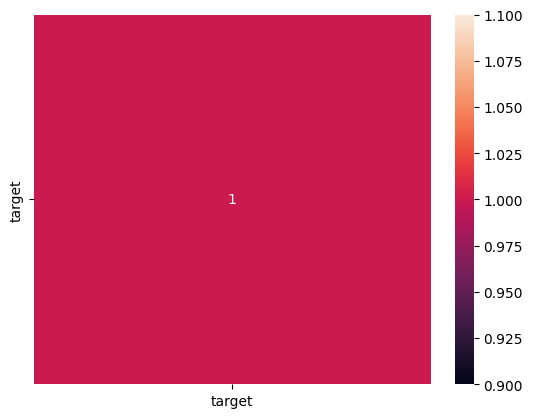

In [130]:
sns.heatmap(data=df_train.corr(numeric_only=True), annot=True)

In [138]:
df_flight_delay.groupby(by="airport_departure")["delay"].mean().sort_values(ascending=False).round(0)

airport_departure
RTM    506.0
KBP    341.0
VOG    328.0
BDS    202.0
AYT    160.0
       ...  
STR      0.0
TPS      0.0
TLL      0.0
BGF      NaN
MTS      NaN
Name: delay, Length: 134, dtype: float64

In [139]:
df_flight_delay.groupby(by="airport_departure")["delay"].count().sort_values(ascending=False).round(0)

airport_departure
TUN    42522
DJE    10252
ORY     6755
MIR     5248
MRS     2845
       ...  
RAK        1
TMR        1
TPS        1
BGF        0
MTS        0
Name: delay, Length: 134, dtype: int64

In [140]:
df_flight_delay["flight_number"].nunique()

1912

In [141]:
df_flight_delay["aircraft_code"].nunique()

70

In [143]:
df_flight_delay["aircraft_code"].value_counts(ascending=False)

aircraft_code
TU 320IMW    5084
TU 320IMT    5017
TU 320IMU    5006
TU 320IMR    4997
TU 320IMV    4989
             ... 
6P M87TRJ       6
TU CR9CR9       6
TU 32A32A       2
TU CR9XXX       2
TU 320320       1
Name: count, Length: 70, dtype: int64

In [153]:
df_flight_delay[df_flight_delay["delay"] > 0.0].groupby("aircraft_code")["delay"].mean().round(0).sort_values(ascending=False)

aircraft_code
OL 321ABY    257.0
5K 345TFX    236.0
5M 343JAI    195.0
GJ 734CGC    178.0
UG CR9ISA    160.0
             ...  
GJ 733EWE     44.0
TU 31AIMK     44.0
BJ 320INC     43.0
6P M87TRJ     29.0
BJ 320INA     25.0
Name: delay, Length: 61, dtype: float64

In [156]:
df_flight_delay[(df_flight_delay["delay"] > 0.0)].groupby(["aircraft_code", df_flight_delay.sch_time_dep.dt.year])["delay"].mean().round(0).sort_values(ascending=False)

aircraft_code  sch_time_dep
GJ 734CGC      2017            295.0
OL 321ABY      2018            257.0
UG AT7LBE      2017            249.0
5K 345TFX      2018            237.0
               2017            236.0
                               ...  
6P M87TRJ      2017             29.0
BJ 320INQ      2017             29.0
UG AT7LBD      2017             27.0
BJ 320INA      2017             19.0
BJ 320INR      2018             10.0
Name: delay, Length: 129, dtype: float64

In [157]:
df_flight_delay.nunique()

flight_date           1096
flight_number         1912
airport_departure      134
airport_arrival        130
sch_time_dep         88709
sch_time_arr         92423
status                   5
aircraft_code           70
delay                  968
dtype: int64

In [160]:
unique_list_dep = df_flight_delay["airport_departure"].unique().tolist()
un_li = df_flight_delay[~df_flight_delay["airport_arrival"].isin(unique_list_dep)]
un_li

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
87561,2018-06-20,GJT 0409,DJE,BGY,2018-06-20 21:25:00,2018-06-20 23:40:00,ATA,GJ 733LGC,0.0


In [161]:
unique_list_dep = df_flight_delay["airport_arrival"].unique().tolist()
un_li = df_flight_delay[~df_flight_delay["airport_departure"].isin(unique_list_dep)]
un_li

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay
66123,2017-09-03,DAT 4445,KEF,DJE,2017-09-03 18:30:00,2017-09-03 23:50:00,ATA,D4 320CQP,0.0
76737,2018-06-03,TU 9095,AAL,DJE,2018-06-03 17:00:00,2018-06-03 20:45:00,ATA,GJ 733EWE,0.0
79479,2018-06-15,TU 9021,TLL,DJE,2018-06-15 19:50:00,2018-06-16 00:10:00,ATA,GJ 733LGC,0.0
92116,2018-07-01,TU 9655,KTW,MIR,2018-07-01 01:30:00,2018-07-01 04:00:00,ATA,GJ 734MGC,100.0
99772,2018-12-29,X9 9002,STR,TUN,2018-12-29 11:45:00,2018-12-29 14:00:00,ATA,X9 320VEB,0.0


In [166]:
# Werte in Spalte_A, die NICHT in Spalte_B vorkommen
# ergebnis = df_flight_delay[~df_flight_delay['airport_arrival'].isin(df_flight_delay['airport_departure'])]['airport_arrival'].unique().tolist()
ergebnis = df_flight_delay[~df_flight_delay['airport_departure'].isin(df_flight_delay['airport_arrival'])]['airport_arrival'].unique().tolist()
ergebnis

['DJE', 'MIR', 'TUN']

In [168]:
unique_list_arr = df_flight_delay["airport_arrival"].unique().tolist()
unique_list_dep = df_flight_delay["airport_departure"].unique().tolist()

# Elemente, die in A, aber nicht in B sind
diff_a_b = set(unique_list_dep) - set(unique_list_arr)
diff_a_b

{'AAL', 'KEF', 'KTW', 'STR', 'TLL'}

In [173]:
df_flight_delay.groupby(by=["airport_departure", "airport_arrival"])["flight_number"].unique().apply(sorted)

airport_departure  airport_arrival
AAE                TUN                                                [TU 2611 ]
AAL                DJE                                                [TU 9095 ]
ABJ                ABJ                [AOG 0000 , TU 0397 , TU 0398 , WKL 0000 ]
                   BKO                                                [TU 0399 ]
                   COO                                                [TU 0401 ]
                                                         ...                    
YUL                YUL                                               [AOG 0000 ]
ZRH                DJE                            [TU 0485 , TU 0603 , TU 9001 ]
                   GVA                            [TU 0485 , TU 0700 , TU 0701 ]
                   MIR                                                [TU 0603 ]
                   TUN                            [TU 0485 , TU 0603 , TU 0701 ]
Name: flight_number, Length: 761, dtype: object

In [174]:
df_flight_delay_hours = df_flight_delay.copy()
df_flight_delay_hours["sch_time_dep_hour"] = df_flight_delay_hours["sch_time_dep"].dt.hour
df_flight_delay_hours["sch_time_arr_hour"] = df_flight_delay_hours["sch_time_arr"].dt.hour
df_flight_delay_hours.head()

,flight_date,flight_number,airport_departure,airport_arrival,sch_time_dep,sch_time_arr,status,aircraft_code,delay,sch_time_dep_hour,sch_time_arr_hour
0,2016-01-03,TU 0712,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0,10,12
1,2016-01-13,TU 0757,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0,15,16
2,2016-01-16,TU 0214,TUN,IST,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0,4,6
3,2016-01-17,TU 0480,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0,14,17
4,2016-01-17,TU 0338,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0,14,15


In [179]:
df_flight_delay_hours[df_flight_delay_hours["delay"] > 0.0].groupby(by=["sch_time_dep_hour", "airport_departure"]).size().sort_values(ascending=False)

sch_time_dep_hour  airport_departure
7                  TUN                  4553
13                 TUN                  3758
8                  TUN                  3105
14                 TUN                  3003
6                  TUN                  2450
                                        ... 
0                  IST                     1
23                 TLS                     1
0                  GAE                     1
                   ATH                     1
                   ARN                     1
Length: 875, dtype: int64

In [191]:
df_flight_delay_hours[df_flight_delay_hours["delay"] > 0.0].groupby(by=["sch_time_dep_hour", "airport_departure"])["delay"].mean().round(0).sort_values(ascending=False)

sch_time_dep_hour  airport_departure
19                 ZRH                  1528.0
6                  LJU                   824.0
16                 IST                   770.0
20                 SXF                   734.0
6                  NCE                   730.0
                                         ...  
13                 ZRH                     5.0
3                  MRS                     4.0
17                 NBE                     3.0
4                  NBE                     3.0
5                  ORY                     3.0
Name: delay, Length: 875, dtype: float64

In [193]:
df_flight_delay_hours.delay.describe()

count    107833.000000
mean         48.733013
std         117.135562
min           0.000000
25%           0.000000
50%          14.000000
75%          43.000000
max        3451.000000
Name: delay, dtype: float64

<Axes: xlabel='delay', ylabel='Count'>

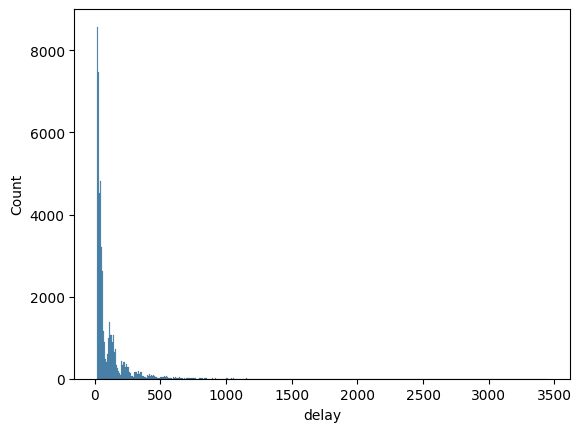

In [197]:
sns.histplot(data=df_flight_delay_hours[df_flight_delay_hours["delay"] > 15], x="delay")

<Axes: xlabel='delay'>

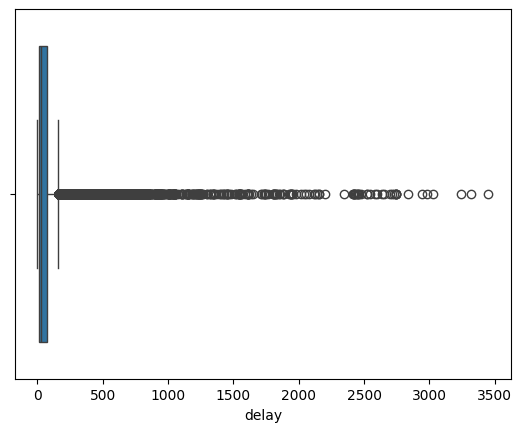

In [199]:
sns.boxplot(data=df_flight_delay_hours[df_flight_delay_hours["delay"] > 0], x="delay")